<h1 style="color:green;font-weight:700;text-align:center;">Train Test Split</h1>

---

- In order to check our model's accuracy we should not train our model with the whole dataset
- We have to split up the Training Data & the Testing Data to measure the accuracy of our model for the data it hasn't seen
- In this way it will be able to predict better results
- For this we will use the sklearns test_train_split method

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("carprices.csv")
df.head()

,Mileage,Age(yrs),Sell Price($)
0,69000,6,18000
1,35000,3,34000
2,57000,5,26100
3,22500,2,40000
4,46000,4,31500


#### Car Mileage Vs Sell Price ($)

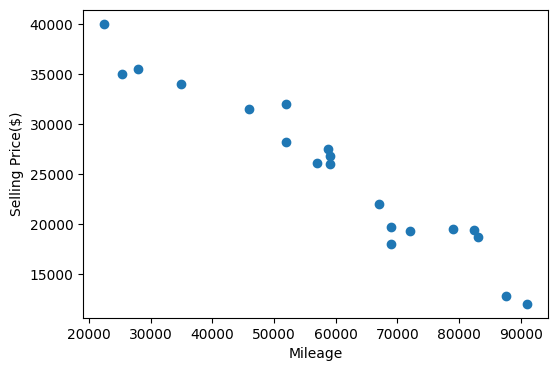

In [3]:
plt.figure(figsize=(6,4))
plt.scatter(x=df['Mileage'],y=df['Sell Price($)'])
plt.xlabel("Mileage")
plt.ylabel("Selling Price($)")
plt.show()

#### Car Age Vs Sell Price ($)

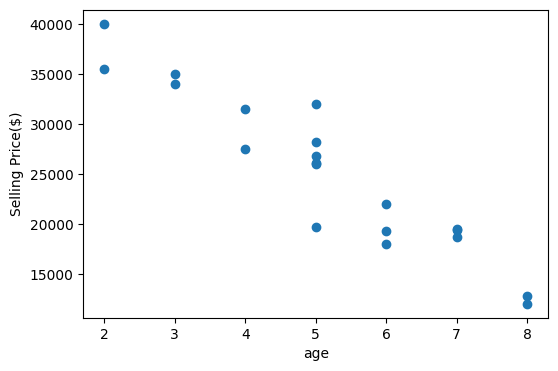

In [4]:
plt.figure(figsize=(6,4))
plt.scatter(df['Age(yrs)'],df['Sell Price($)'])
plt.xlabel("age")
plt.ylabel("Selling Price($)")
plt.show()

**Looking at above two scatter plots, using linear regression model makes sense as we can clearly see a linear relationship between our dependant (i.e. Sell Price) and independant variables (i.e. car age and car mileage)**

The approach we are going to use here is to split available data in two sets:

- Training: We will train our model on this dataset
- Testing: We will use this subset to make actual predictions using trained model

**The reason we don't use same training set for testing is because our model has seen those samples before, using same samples for making predictions might give us wrong impression about accuracy of our model. It is like you ask same questions in exam paper as you tought the students in the class.**

In [5]:
X = df[['Mileage','Age(yrs)']]
y = df['Sell Price($)']

In [6]:
X.head()

,Mileage,Age(yrs)
0,69000,6
1,35000,3
2,57000,5
3,22500,2
4,46000,4


In [7]:
y.head()

0    18000
1    34000
2    26100
3    40000
4    31500
Name: Sell Price($), dtype: int64

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=10) #random_state argument

In [9]:
X_train.head()

,Mileage,Age(yrs)
13,58780,4
2,57000,5
14,82450,7
8,91000,8
17,69000,5


In [10]:
len(X_train)

14

In [11]:
len(X_test)

6

## Training our model:

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
X_test

,Mileage,Age(yrs)
7,72000,6
10,83000,7
5,59000,5
6,52000,5
3,22500,2
18,87600,8


In [14]:
model.predict(X_test)

array([20668.52722622, 16762.33242213, 25160.18381011, 27209.30003936,
       37903.32633702, 14729.61531335])

In [15]:
y_test

7     19300
10    18700
5     26750
6     32000
3     40000
18    12800
Name: Sell Price($), dtype: int64

In [16]:
model.score(X_test,y_test)*100

92.1242248377633